# 02. LPIPS Resolution Sweep

This notebook focuses on image resolution.

It is motivated by your observation that LPIPS may give worse results in our earlier work. One possible reason is that very small images do not preserve enough perceptual detail for LPIPS to help.

Questions answered here:

- Does LPIPS become more useful at larger resolutions?
- Is the LPIPS-vs-MSE gap different at `32`, `64`, `96`, and `128`?


In [ ]:
!pip install torch torchvision lpips matplotlib pandas pillow seaborn

import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, Dataset, Subset

import lpips

sns.set_theme(style="whitegrid")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
FIG_DIR = BASE_DIR / "generated_figures"
FIG_DIR.mkdir(exist_ok=True)
print("Using device:", DEVICE)


Using device: cuda


In [ ]:
# Reproducibility helps make LPIPS-vs-MSE comparisons fair.
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
STL10_CLASSES = CIFAR10_CLASSES

class ConvAutoencoder(nn.Module):
    """Small convolutional autoencoder used across the notebooks."""
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def to_lpips_range(x: torch.Tensor) -> torch.Tensor:
    # LPIPS expects images in [-1, 1].
    return x * 2.0 - 1.0


def psnr(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    mse = torch.mean((pred - target) ** 2, dim=(1, 2, 3))
    return 10.0 * torch.log10(1.0 / (mse + 1e-8))


def build_transform(image_size: int):
    return T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
    ])


def degrade_image(image: torch.Tensor, mode: str) -> torch.Tensor:
    image = image.clone()
    if mode == "identity":
        return image
    if mode == "gaussian_noise":
        noise = 0.08 * torch.randn_like(image)
        return torch.clamp(image + noise, 0.0, 1.0)
    if mode == "blur":
        return TF.gaussian_blur(image, kernel_size=[5, 5], sigma=[1.2, 1.2])
    if mode == "downsample":
        h, w = image.shape[-2:]
        small = TF.resize(image, [max(8, h // 4), max(8, w // 4)], antialias=True)
        return TF.resize(small, [h, w], antialias=True)
    if mode == "shift":
        # Small spatial shift is useful because LPIPS and MSE can react differently.
        return torch.roll(image, shifts=(2, 2), dims=(1, 2))
    raise ValueError(f"Unknown degradation mode: {mode}")


class ReconstructionWrapper(Dataset):
    def __init__(self, base_dataset, degradation="identity"):
        self.base_dataset = base_dataset
        self.degradation = degradation

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        sample = self.base_dataset[idx]
        image = sample[0] if isinstance(sample, tuple) else sample
        degraded = degrade_image(image, self.degradation)
        return degraded, image


class RepeatedSingleImageDataset(Dataset):
    def __init__(self, image: torch.Tensor, repeats: int = 256, degradation: str = "identity"):
        self.image = image
        self.repeats = repeats
        self.degradation = degradation

    def __len__(self):
        return self.repeats

    def __getitem__(self, idx):
        degraded = degrade_image(self.image, self.degradation)
        return degraded, self.image


def get_dataset(dataset_name: str, image_size: int):
    transform = build_transform(image_size)
    name = dataset_name.upper()
    if name == "CIFAR10":
        return torchvision.datasets.CIFAR10(root=str(DATA_DIR), train=True, download=True, transform=transform)
    if name == "CIFAR100":
        return torchvision.datasets.CIFAR100(root=str(DATA_DIR), train=True, download=True, transform=transform)
    if name == "STL10":
        return torchvision.datasets.STL10(root=str(DATA_DIR), split="train", download=True, transform=transform)
    if name == "CELEBA":
        return torchvision.datasets.CelebA(root=str(DATA_DIR), split="train", download=True, transform=transform)
    raise ValueError(f"Unsupported dataset: {dataset_name}")


def get_targets(dataset):
    if hasattr(dataset, "targets"):
        return [int(x) for x in dataset.targets]
    if hasattr(dataset, "labels"):
        return [int(x) for x in dataset.labels]
    return None


def filter_by_class(dataset, dataset_name: str, class_name: str, max_items: int = 1000):
    if class_name == "all":
        return dataset
    targets = get_targets(dataset)
    if targets is None:
        raise ValueError(f"Dataset {dataset_name} does not expose simple class labels for filtering.")
    if dataset_name.upper() == "CIFAR10":
        class_index = CIFAR10_CLASSES.index(class_name)
    elif dataset_name.upper() == "STL10":
        class_index = STL10_CLASSES.index(class_name)
    else:
        raise ValueError(f"Class filtering not set up for {dataset_name}.")
    indices = [i for i, target in enumerate(targets) if target == class_index][:max_items]
    return Subset(dataset, indices)


def train_two_models(train_loader, epochs=5, lpips_net="vgg"):
    base_model = ConvAutoencoder().to(DEVICE)
    model_lpips = ConvAutoencoder().to(DEVICE)
    model_mse = ConvAutoencoder().to(DEVICE)
    model_lpips.load_state_dict(base_model.state_dict())
    model_mse.load_state_dict(base_model.state_dict())

    optimizer_lpips = optim.Adam(model_lpips.parameters(), lr=1e-4)
    optimizer_mse = optim.Adam(model_mse.parameters(), lr=1e-4)
    lpips_loss = lpips.LPIPS(net=lpips_net).to(DEVICE).eval()
    mse_loss = nn.MSELoss()

    history = {"epoch": [], "lpips_train_loss": [], "mse_train_loss": []}

    for epoch in range(1, epochs + 1):
        model_lpips.train()
        model_mse.train()
        running_lpips = 0.0
        running_mse = 0.0
        batches = 0

        for degraded, clean in train_loader:
            degraded = degraded.to(DEVICE)
            clean = clean.to(DEVICE)

            optimizer_lpips.zero_grad()
            pred_lpips = model_lpips(degraded)
            loss_lp = lpips_loss(to_lpips_range(pred_lpips), to_lpips_range(clean)).mean()
            loss_lp.backward()
            optimizer_lpips.step()

            optimizer_mse.zero_grad()
            pred_mse = model_mse(degraded)
            loss_mse = mse_loss(pred_mse, clean)
            loss_mse.backward()
            optimizer_mse.step()

            running_lpips += loss_lp.item()
            running_mse += loss_mse.item()
            batches += 1

        history["epoch"].append(epoch)
        history["lpips_train_loss"].append(running_lpips / batches)
        history["mse_train_loss"].append(running_mse / batches)
        print(f"Epoch {epoch:02d} | LPIPS loss: {history['lpips_train_loss'][-1]:.4f} | MSE loss: {history['mse_train_loss'][-1]:.4f}")

    return model_lpips, model_mse, pd.DataFrame(history), lpips_loss, mse_loss


def evaluate_models(model_lpips, model_mse, loader, lpips_loss, mse_loss):
    model_lpips.eval()
    model_mse.eval()
    rows = []

    with torch.no_grad():
        for degraded, clean in loader:
            degraded = degraded.to(DEVICE)
            clean = clean.to(DEVICE)
            pred_lpips = model_lpips(degraded)
            pred_mse = model_mse(degraded)

            rows.append({
                "lpips_model_lpips": lpips_loss(to_lpips_range(pred_lpips), to_lpips_range(clean)).mean().item(),
                "mse_model_lpips": lpips_loss(to_lpips_range(pred_mse), to_lpips_range(clean)).mean().item(),
                "lpips_model_mse": mse_loss(pred_lpips, clean).item(),
                "mse_model_mse": mse_loss(pred_mse, clean).item(),
                "lpips_model_psnr": psnr(pred_lpips, clean).mean().item(),
                "mse_model_psnr": psnr(pred_mse, clean).mean().item(),
            })
    return pd.DataFrame(rows).mean().to_frame(name="value")


def show_reconstructions(model_lpips, model_mse, loader, title, n=5):
    degraded, clean = next(iter(loader))
    degraded = degraded.to(DEVICE)
    clean = clean.to(DEVICE)
    with torch.no_grad():
        pred_lpips = model_lpips(degraded).cpu()
        pred_mse = model_mse(degraded).cpu()
    degraded = degraded.cpu()
    clean = clean.cpu()

    n = min(n, degraded.size(0))
    plt.figure(figsize=(3 * n, 8))
    for i in range(n):
        plt.subplot(4, n, i + 1)
        plt.imshow(degraded[i].permute(1, 2, 0))
        plt.title("Input")
        plt.axis("off")

        plt.subplot(4, n, n + i + 1)
        plt.imshow(clean[i].permute(1, 2, 0))
        plt.title("Target")
        plt.axis("off")

        plt.subplot(4, n, 2 * n + i + 1)
        plt.imshow(pred_lpips[i].permute(1, 2, 0))
        plt.title("LPIPS")
        plt.axis("off")

        plt.subplot(4, n, 3 * n + i + 1)
        plt.imshow(pred_mse[i].permute(1, 2, 0))
        plt.title("MSE")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [ ]:
DATASET_NAME = "CIFAR10"
CLASS_NAME = "horse"     # Try: "frog" or "all"
DEGRADATION = "gaussian_noise"
RESOLUTIONS = [32, 64, 96, 128]
TRAIN_SAMPLES = 256
VAL_SAMPLES = 64
BATCH_SIZE = 32
EPOCHS = 100
LPIPS_NET = "vgg"


In [ ]:
results = []
example_loaders = {}
example_models = {}

for image_size in RESOLUTIONS:
    print("\nRunning size:", image_size)
    dataset = get_dataset(DATASET_NAME, image_size)
    dataset = filter_by_class(dataset, DATASET_NAME, CLASS_NAME, max_items=TRAIN_SAMPLES + VAL_SAMPLES)

    if isinstance(dataset, Subset):
        indices = dataset.indices
        root_dataset = dataset.dataset
    else:
        indices = list(range(len(dataset)))
        root_dataset = dataset

    train_indices = indices[:TRAIN_SAMPLES]
    val_indices = indices[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]
    if len(val_indices) == 0:
        val_indices = indices[:min(VAL_SAMPLES, len(indices))]

    train_dataset = ReconstructionWrapper(Subset(root_dataset, train_indices), degradation=DEGRADATION)
    val_dataset = ReconstructionWrapper(Subset(root_dataset, val_indices), degradation=DEGRADATION)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model_lpips, model_mse, history_df, lpips_loss, mse_loss = train_two_models(train_loader, epochs=EPOCHS, lpips_net=LPIPS_NET)
    metrics = evaluate_models(model_lpips, model_mse, val_loader, lpips_loss, mse_loss)

    results.append({
        "resolution": image_size,
        "lpips_model_lpips": metrics.loc["lpips_model_lpips", "value"],
        "mse_model_lpips": metrics.loc["mse_model_lpips", "value"],
        "lpips_model_mse": metrics.loc["lpips_model_mse", "value"],
        "mse_model_mse": metrics.loc["mse_model_mse", "value"],
        "lpips_model_psnr": metrics.loc["lpips_model_psnr", "value"],
        "mse_model_psnr": metrics.loc["mse_model_psnr", "value"],
    })

    example_loaders[image_size] = val_loader
    example_models[image_size] = (model_lpips, model_mse)

results_df = pd.DataFrame(results)
results_df



Running size: 32
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Epoch 01 | LPIPS loss: 0.8307 | MSE loss: 0.0622
Epoch 02 | LPIPS loss: 0.8293 | MSE loss: 0.0620
Epoch 03 | LPIPS loss: 0.8273 | MSE loss: 0.0617
Epoch 04 | LPIPS loss: 0.8243 | MSE loss: 0.0613
Epoch 05 | LPIPS loss: 0.8188 | MSE loss: 0.0605
Epoch 06 | LPIPS loss: 0.8099 | MSE loss: 0.0596
Epoch 07 | LPIPS loss: 0.7995 | MSE loss: 0.0583
Epoch 08 | LPIPS loss: 0.7631 | MSE loss: 0.0554
Epoch 09 | LPIPS loss: 0.6663 | MSE loss: 0.0499
Epoch 10 | LPIPS loss: 0.6296 | MSE loss: 0.0418
Epoch 11 | LPIPS loss: 0.6194 | MSE loss: 0.0336
Epoch 12 | LPIPS loss: 0.6131 | MSE loss: 0.0289
Epoch 13 | LPIPS loss: 0.6083 | MSE loss: 0.0258
Epoch 14 | LPIPS loss: 0.6039 | MSE loss: 0.0236
Epoch 15 | LPIPS loss: 0.6004 | MSE loss: 0.0224
Epoch 16 | LPIPS loss: 0.5973 | MSE loss: 0.0215
Epoch 17 | LPIPS loss: 0.5940 | MSE loss: 0.0208
Epoch 18 | LPIPS loss: 0.5916 | MSE loss: 0.0201
Epoch 19 | LPIPS loss: 0.5895 |

,resolution,lpips_model_lpips,mse_model_lpips,lpips_model_mse,mse_model_mse,lpips_model_psnr,mse_model_psnr
0,32,0.391006,0.399936,0.056541,0.007892,13.081976,21.652834
1,64,0.180915,0.337378,0.016423,0.002963,18.426744,25.901748
2,96,0.214358,0.314901,0.056045,0.002143,13.058279,27.498178
3,128,0.174906,0.343146,0.050156,0.001842,13.521968,28.470848


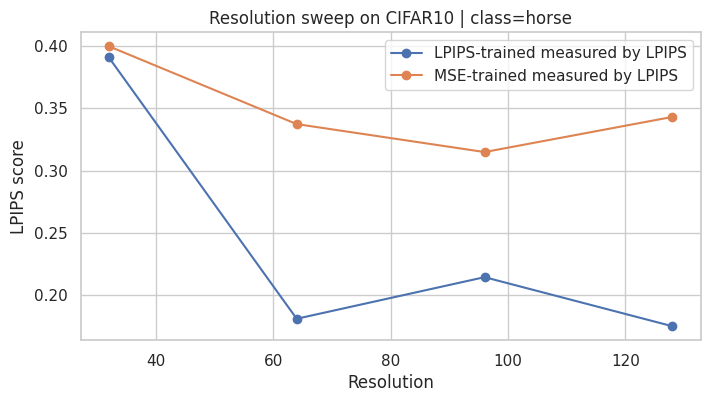

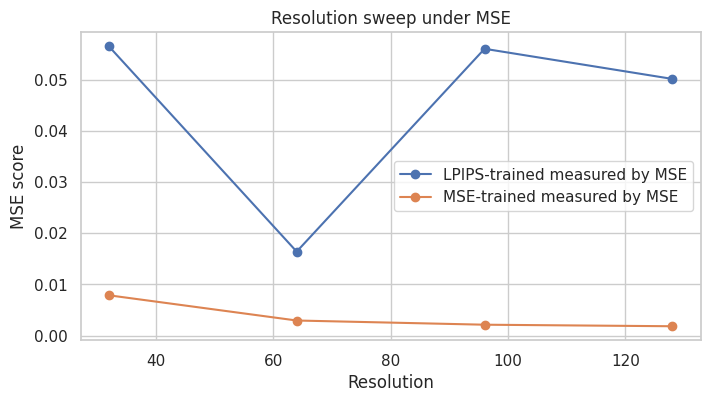

In [ ]:
# LPIPS metric vs resolution.
plt.figure(figsize=(8, 4))
plt.plot(results_df["resolution"], results_df["lpips_model_lpips"], marker="o", label="LPIPS-trained measured by LPIPS")
plt.plot(results_df["resolution"], results_df["mse_model_lpips"], marker="o", label="MSE-trained measured by LPIPS")
plt.xlabel("Resolution")
plt.ylabel("LPIPS score")
plt.title(f"Resolution sweep on {DATASET_NAME} | class={CLASS_NAME}")
plt.legend()
plt.show()

# MSE metric vs resolution.
plt.figure(figsize=(8, 4))
plt.plot(results_df["resolution"], results_df["lpips_model_mse"], marker="o", label="LPIPS-trained measured by MSE")
plt.plot(results_df["resolution"], results_df["mse_model_mse"], marker="o", label="MSE-trained measured by MSE")
plt.xlabel("Resolution")
plt.ylabel("MSE score")
plt.title("Resolution sweep under MSE")
plt.legend()
plt.show()


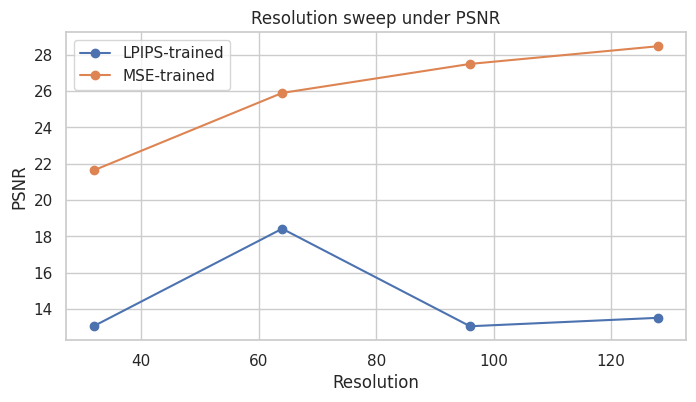

In [ ]:
# PSNR adds another conventional restoration metric.
plt.figure(figsize=(8, 4))
plt.plot(results_df["resolution"], results_df["lpips_model_psnr"], marker="o", label="LPIPS-trained")
plt.plot(results_df["resolution"], results_df["mse_model_psnr"], marker="o", label="MSE-trained")
plt.xlabel("Resolution")
plt.ylabel("PSNR")
plt.title("Resolution sweep under PSNR")
plt.legend()
plt.show()


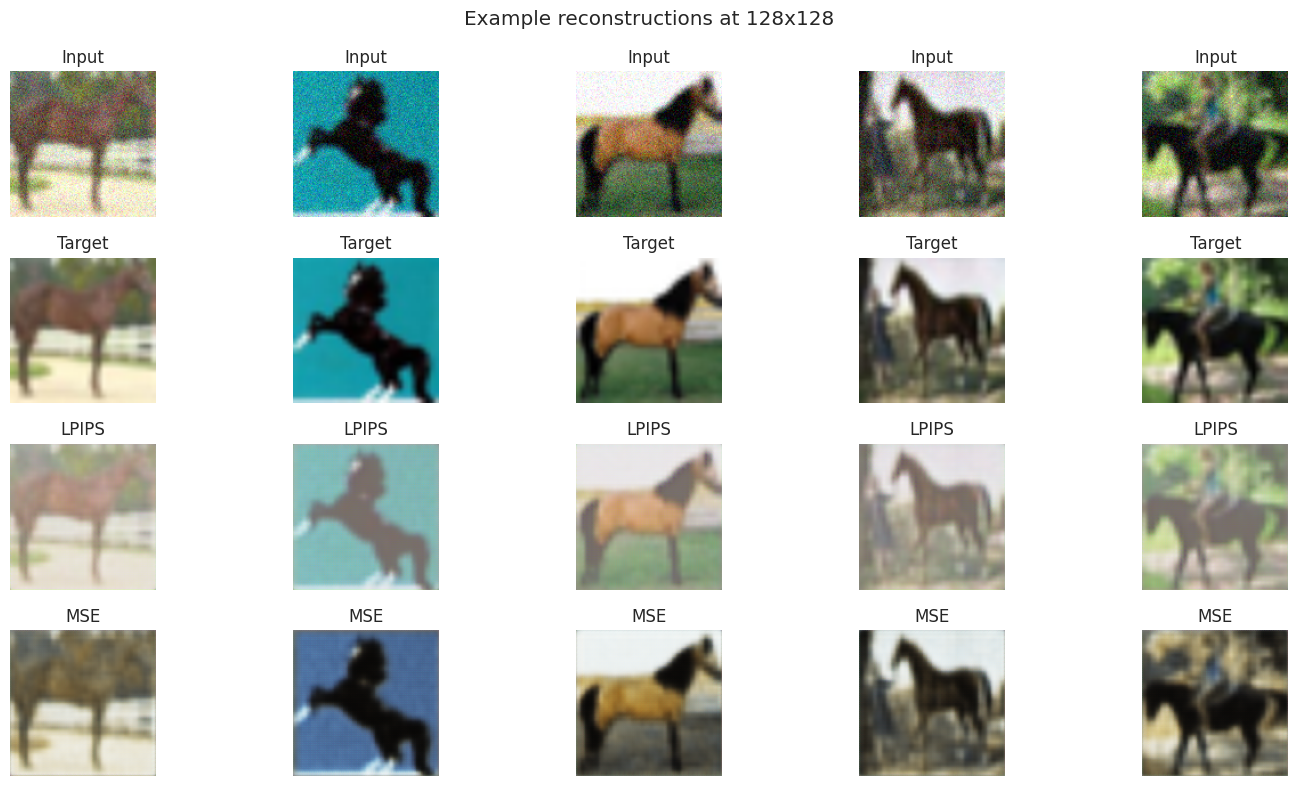

In [ ]:
# Look at one reconstruction grid from the highest resolution.
best_size = RESOLUTIONS[-1]
model_lpips, model_mse = example_models[best_size]
show_reconstructions(model_lpips, model_mse, example_loaders[best_size], title=f"Example reconstructions at {best_size}x{best_size}")
